In [ ]:
# BLOCK 1 - Imports & Grundkonfiguration
import os
import time   
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

from sklearn.model_selection import train_test_split

BASE_PATH = os.path.abspath(".")   

# Folders are located directly under this root:
TRAIN_DIR = os.path.join(BASE_PATH, "seg_train")
TEST_DIR  = os.path.join(BASE_PATH, "seg_test")
PRED_DIR  = os.path.join(BASE_PATH, "seg_pred") 

print("BASE_PATH:", BASE_PATH)
print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR :", TEST_DIR)
print("PRED_DIR :", PRED_DIR)

BATCH_SIZE = 32   
EPOCHS = 20       # fewer epochs for faster training
LR = 1e-4         # Learn rate
VAL_RATIO = 0.15  # 15% of training data used as validation

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
pin_memory = (device.type == "cuda")

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)

c:\Users\Med Amin\Downloads\Project2_Intel\Project2_Intel
BASE_PATH: c:\Users\Med Amin\Downloads\Project2_Intel\Project2_Intel
TRAIN_DIR: c:\Users\Med Amin\Downloads\Project2_Intel\Project2_Intel\seg_train
TEST_DIR : c:\Users\Med Amin\Downloads\Project2_Intel\Project2_Intel\seg_test
PRED_DIR : c:\Users\Med Amin\Downloads\Project2_Intel\Project2_Intel\seg_pred
Device: cuda
Torch: 2.5.1+cu121
CUDA available: True
GPU name: NVIDIA GeForce RTX 3050


In [ ]:
# -------------------------------------------------------------
# Help function 1: Images in one folder
# -------------------------------------------------------------
import os

def count_images_in_folder(path):
    if not os.path.exists(path):
        return 0
    
    count = 0
    for root, dirs, files in os.walk(path):
        for f in files:
            if f.lower().endswith((".jpg", ".jpeg", ".png")):
                count += 1
    return count


TRAIN_COUNT = count_images_in_folder(TRAIN_DIR)
TEST_COUNT  = count_images_in_folder(TEST_DIR)
PRED_COUNT  = count_images_in_folder(PRED_DIR)

print("Anzahl Bilder pro Haupt-Ordner:")
print(f"TRAIN_DIR ({TRAIN_DIR}): {TRAIN_COUNT}")
print(f"TEST_DIR  ({TEST_DIR}): {TEST_COUNT}")
print(f"PRED_DIR  ({PRED_DIR}): {PRED_COUNT}")


# -------------------------------------------------------------
# Help function 2: Images each class
# -------------------------------------------------------------
def count_images_per_class(path):
    class_counts = {}

    if not os.path.exists(path):
        return class_counts

    # Jeder Unterordner = eine Klasse
    for class_name in os.listdir(path):
        class_path = os.path.join(path, class_name)

        if not os.path.isdir(class_path):
            continue

        # Counting Images in the folder
        count = sum(
            f.lower().endswith((".jpg", ".jpeg", ".png"))
            for f in os.listdir(class_path)
        )

        class_counts[class_name] = count

    return class_counts


train_classes = count_images_per_class(TRAIN_DIR)

print("\nBilder pro Klasse im TRAIN_DIR:")
for cls, cnt in train_classes.items():
    print(f"{cls:15} → {cnt} Bilder")


Anzahl Bilder pro Haupt-Ordner:
TRAIN_DIR (c:\Users\Med Amin\Downloads\Project2_Intel\Project2_Intel\seg_train): 14034
TEST_DIR  (c:\Users\Med Amin\Downloads\Project2_Intel\Project2_Intel\seg_test): 3000
PRED_DIR  (c:\Users\Med Amin\Downloads\Project2_Intel\Project2_Intel\seg_pred): 7301

Bilder pro Klasse im TRAIN_DIR:
buildings       → 2191 Bilder
forest          → 2271 Bilder
glacier         → 2404 Bilder
mountain        → 2512 Bilder
sea             → 2274 Bilder
street          → 2382 Bilder


In [ ]:
# BLOCK 2 - Transforms & Datasets

# Mean and standard deviation values from the ImageNet dataset,
# on which most pretrained models are trained.
# They ensure that our input images match the brightness and color distribution
# of the images the model originally learned fro
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

# Training data transforms: resize, augment, convert to tensor, normalize
train_tfm = transforms.Compose([
    transforms.Resize((224, 224)),      # 150x150 → 224x224 (augmentation) for better generalization
    transforms.RandomHorizontalFlip(),  # random left/right flip (augmentation)
    transforms.ToTensor(),              # [0,255] → [0,1]
    transforms.Normalize(imagenet_mean, imagenet_std),  # adapt the images to ImageNet
])

# Validation/Test data transforms: same size + normalization, no randomness
val_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

# 1) Full training dataset (without transforms) for targets/classes
# ----------------------------------------------------------------------------
# ImageFolder loads the images dataset WITHOUT transforms based on the train folder structure.
# Each subfolder inside TRAIN_DIR represents one class.
#
#
# Then ImageFolder detects:
#   classes = ["buildings", "forest", "sea"]
# and automatically assigns label IDs:
#
# Here we load the version WITHOUT transforms, only to:
#   - read the class names
#   - determine the number of classes
#   - later create a train/validation split
# ----------------------------------------------------------------------------

full_train_dataset = datasets.ImageFolder(TRAIN_DIR)

print("Klassen:", full_train_dataset.classes)
print("Anzahl Klassen:", len(full_train_dataset.classes))

img, label = full_train_dataset[0]
print("image with the index 0 (first img): "
      f"Label-IDs: {label} "
      f"Label: {full_train_dataset.classes[label]}")


# 2) Train/Val-Split 
indices = np.arange(len(full_train_dataset))
train_idx, val_idx = train_test_split(
    indices,
    test_size=VAL_RATIO,
    stratify=full_train_dataset.targets,
    random_state=42
)
print(f"training indexes : {train_idx} "
      f"validation indexes : {val_idx}")


# 3) Datasets MIT Transforms
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_tfm)
val_dataset   = datasets.ImageFolder(TRAIN_DIR, transform=val_tfm)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=val_tfm)

# 4) Subsets für Train/Val
train_ds = Subset(train_dataset, train_idx)
val_ds   = Subset(val_dataset,   val_idx)

# 5) DataLoader
# we load the dataset with Dataloader which will be delivered for the model training
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=pin_memory
)

val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=pin_memory
)

test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=pin_memory
)


Klassen: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Anzahl Klassen: 6
image with the index 0 (first img): Label-IDs: 0 Label: buildings
training indexes : [ 6278 10087  2749 ...  4068   351 10984] validation indexes : [13610 12912  1634 ... 13524 12782 13412]


In [ ]:
# BLOCK 3 - Vision Transformer Model 

# Pretrained Vision Transformer (ViT-B/16, ImageNet-1k)

weights = models.ViT_B_16_Weights.IMAGENET1K_V1
vit = models.vit_b_16(weights=weights)

# Feature extractor mode: train only the classification head.
# Freezes all weights of the Vision Transformer except for the final linear layer.
# The model learns the classification logic, not the feature extraction.
FEATURE_EXTRACTOR = True

if FEATURE_EXTRACTOR:
    for param in vit.parameters():
        param.requires_grad = False

# Replace the classification head
in_features = vit.heads.head.in_features   # load the number of input features to the last layer
num_classes = len(full_train_dataset.classes)
vit.heads.head = nn.Linear(in_features, num_classes)   # replace the last layer number with a new one and connect them to in_features

vit = vit.to(device)
print("Neuer ViT-Head:", vit.heads.head)

# Only trainable parameters (when FEATURE_EXTRACTOR=True, only the head is trainable)
trainable_params = [p for p in vit.parameters() if p.requires_grad]
print("Anzahl trainierbare Parameter:", sum(p.numel() for p in trainable_params))


Neuer ViT-Head: Linear(in_features=768, out_features=6, bias=True)
Anzahl trainierbare Parameter: 4614


In [34]:
# BLOCK 4 - Loss & Optimizer

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(trainable_params, lr=LR, weight_decay=1e-4)


In [ ]:
# BLOCK 5 - Trainings- und Evaluationsfunktionen

def train_one_epoch(model, loader, optimizer, loss_func, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        # The image goes through the network and the output logits are saved
        outputs = model(images)             
        loss = loss_func(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Train Accuracy berechnen
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / len(loader)
    acc = 100.0 * correct / total

    return avg_loss, acc

def evaluate(model, loader, loss_func, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = loss_func(outputs, labels)
            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    avg_loss = running_loss / len(loader)
    acc = 100.0 * correct / total
    return avg_loss, acc


In [ ]:
# BLOCK 6  Training Loop
best_val_acc = 0.0
history = {
    "train_acc": [],
    "val_acc": [],
    "train_loss": [],
    "val_loss": []
}
for epoch in range(EPOCHS):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(vit, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(vit, val_loader, criterion, device)

    epoch_time = time.time() - start_time

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% || "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}% || "
        f"Time: {epoch_time:.1f} s"
    )
    
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(vit.state_dict(), "best_vit_intel_group4.pth")
        print(f"  -> New best ViT model saved (Val Acc: {best_val_acc:.2f}%)")

print(f"\nBeste Validation-Accuracy (ViT): {best_val_acc:.2f}%")


Epoch [1/20] Train Loss: 0.8199 | Train Acc: 77.48% || Val Loss: 0.4409 | Val Acc: 87.56% || Time: 302.9 s
  -> New best ViT model saved (Val Acc: 87.56%)
Epoch [2/20] Train Loss: 0.3618 | Train Acc: 89.50% || Val Loss: 0.3229 | Val Acc: 89.84% || Time: 260.8 s
  -> New best ViT model saved (Val Acc: 89.84%)
Epoch [3/20] Train Loss: 0.2875 | Train Acc: 90.95% || Val Loss: 0.2811 | Val Acc: 90.12% || Time: 267.5 s
  -> New best ViT model saved (Val Acc: 90.12%)
Epoch [4/20] Train Loss: 0.2550 | Train Acc: 91.73% || Val Loss: 0.2587 | Val Acc: 90.98% || Time: 273.8 s
  -> New best ViT model saved (Val Acc: 90.98%)
Epoch [5/20] Train Loss: 0.2356 | Train Acc: 92.34% || Val Loss: 0.2444 | Val Acc: 91.07% || Time: 231.5 s
  -> New best ViT model saved (Val Acc: 91.07%)
Epoch [6/20] Train Loss: 0.2219 | Train Acc: 92.55% || Val Loss: 0.2350 | Val Acc: 91.45% || Time: 238.8 s
  -> New best ViT model saved (Val Acc: 91.45%)
Epoch [7/20] Train Loss: 0.2124 | Train Acc: 92.97% || Val Loss: 0.227

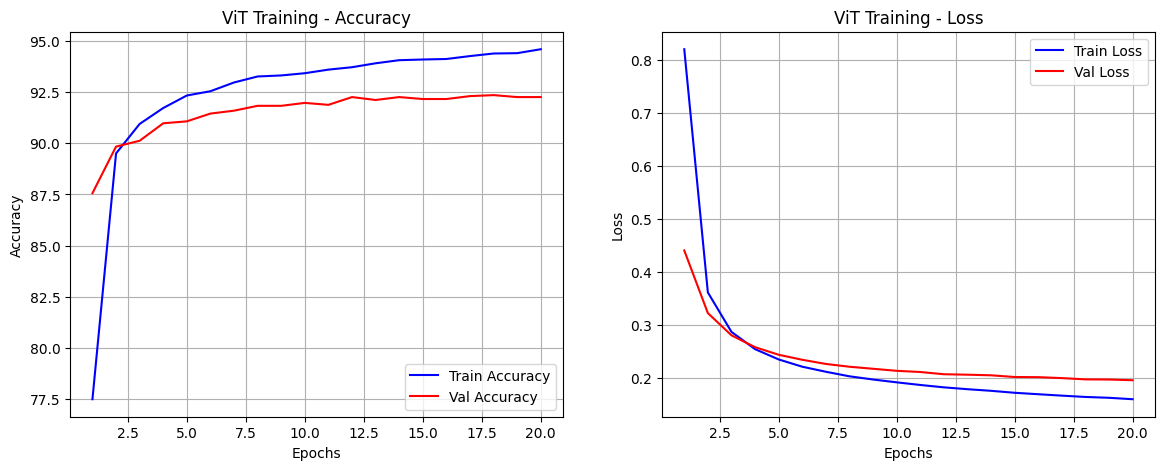

In [40]:
import matplotlib.pyplot as plt

def plot_history(history, title="Training History"):
    epochs = range(1, len(history["train_acc"]) + 1)

    plt.figure(figsize=(14,5))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_acc"], "b-", label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], "r-", label="Val Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_loss"], "b-", label="Train Loss")
    plt.plot(epochs, history["val_loss"], "r-", label="Val Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.show()

# Kurve plotten
plot_history(history, "ViT Training")


Both accuracy and loss curves show fast and stable learning.
The validation curves closely follow the training curves, which means the model performs well an shows no signs of overfitting.

In [ ]:
# here we will evaluate the test images

from sklearn.metrics import classification_report, confusion_matrix

# Load the best saved ViT model into the current model instance
vit.load_state_dict(torch.load("best_vit_intel_group4.pth", map_location=device))
vit.eval()  # Activate evaluation mode (disables Dropout/BatchNorm updates)

all_preds = []   # List to store all model predictions
all_labels = []  # List to store all ground-truth labels

# No gradients needed 
with torch.no_grad():
    # Iterate through the entire test set (prepared earlier with the dataloader)
    for images, labels in test_loader:
        images = images.to(device)          # Move images to GPU/CPU depending on device
        
        outputs = vit(images)               # Compute model outputs
        preds = outputs.argmax(dim=1)       # Select the class with the highest probability

        # Store predictions and true labels on CPU
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Calculate test accuracy: percentage of correct predictions
acc = (np.array(all_preds) == np.array(all_labels)).mean() * 100
print(f"\nTest Accuracy: {acc:.2f}%")

# Classification report (Precision, Recall, F1-score per class)
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

# Confusion matrix (shows misclassifications between classes)
print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_preds))


C:\Users\Med Amin\AppData\Local\Temp\ipykernel_260\3548658162.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vit.load_state_dict(torch.load("best_vit_intel_group4.pth",


Test Accuracy: 93.43%

Classification Report:
              precision    recall  f1-score   support

   buildings       0.92      0.95      0.93       437
      forest       1.00      0.99      1.00       474
     glacier       0.91      0.85      0.88       553
    mountain       0.87      0.91      0.89       525
         sea       0.96      0.99      0.98       510
      street       0.95      0.93      0.94       501

    accuracy                           0.93      3000
   macro avg       0.94      0.94      0.94      3000
weighted avg       0.93      0.93      0.93      3000


Confusion Matrix:
[[414   0   0   0   1  22]
 [  0 471   0   3   0   0]
 [  1   0 470  65  14   3]
 [  0   0  42 477   4   2]
 [  1   0   3   2 504   0]
 [ 33   0   0   1   0 467]]


In [ ]:
# here we will evaluate the prediction folder
import os
import torch
import pandas as pd
from torchvision import transforms
from PIL import Image

pred_folder = "seg_pred"
output_csv = "pred.csv"

class_names = full_train_dataset.classes  # ["buildings", "forest", "glacier", "mountain", "sea", "street"]

# --- Transform ---
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Get the device the model is using
device = next(vit.parameters()).device

# Sort image files alphabetically (by numeric filename)
image_files = sorted(
    [f for f in os.listdir(pred_folder)],
    key=lambda x: int(os.path.splitext(x)[0])
)

rows = []

for img_name in image_files:
    # Load image and transform it into tensor format, e.g., [3, 224, 224]
    img_path = os.path.join(pred_folder, img_name)
    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    vit.eval()  # evaluation mode
    with torch.no_grad():  # no gradient calculation needed
        outputs = vit(img_tensor)  # raw outputs (logits) of the model
        probs = torch.softmax(outputs, dim=1).cpu().numpy()[0]  # convert logits to probabilities

    # Create a row for the CSV
    row = {"image": img_name}
    for class_name, p in zip(class_names, probs):
        row[class_name] = float(p)  # add prediction value for each class

    rows.append(row)

df = pd.DataFrame(rows)
df.to_csv(output_csv, index=False)

print(f"pred.csv successfully created with {len(df)} rows.")
df.head()


pred.csv erfolgreich erzeugt mit 7301 Zeilen.


,image,buildings,forest,glacier,mountain,sea,street
0,3.jpg,0.001520,0.000289,0.000030,0.000092,0.000250,0.997819
1,5.jpg,0.963192,0.000953,0.000968,0.006736,0.010817,0.017334
2,6.jpg,0.000744,0.000729,0.004155,0.002304,0.991235,0.000833
3,11.jpg,0.001822,0.001267,0.519355,0.472409,0.001310,0.003837
4,14.jpg,0.010189,0.000985,0.005310,0.003218,0.002845,0.977454
